<a href="https://colab.research.google.com/github/SANGHATI23/neurofhir-qc/blob/main/21B_NeuroFHIR_TRACE_REAL_Downstream_ABC_FINAL_BURDEN_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# NeuroFHIR-TRACE — Notebook 21B-REAL-FINAL
## Final Downstream A/B/C Analysis + False-Change Burden Refinement

This notebook performs the predeclared downstream consequence experiment:

- **Model A — Clinical baseline only**
- **Model B — Clinical + raw longitudinal MRI evidence**
- **Model C1 — Clinical + trusted-only MRI evidence**
- **Model C2 — Clinical + reliability-weighted MRI evidence**
- **Model C3 — Clinical + full TRACE reliability context**

### Primary downstream TRACE endpoint
**Reduction in absolute downstream risk-probability movement under empirically sampled same-day technical shifts, C2/C3 vs Model B.**

This endpoint is chosen before examining the final results and does not require TRACE to increase AUROC.

### Secondary endpoints
- AUROC / AUPRC
- Brier score / ECE / calibration slope and intercept
- clean-to-shift degradation
- patient-ranking stability
- top-risk-set consistency
- confidently wrong predictions
- prediction movement on shift-induced false longitudinal-change events

### Technical shift source
The perturbations are not arbitrary Gaussian noise. They are sampled from the **real same-day different-acquisition ADNI1 repeat pairs** established in 19B-REAL.

### Guardrail
This is an informatics robustness experiment. It does not establish clinical safety, diagnostic validity, or patient benefit.


### Final refinement

The earlier binary definition (“any feature affected”) saturated because a single altered biomarker was enough to label a subject-shift pair as a false-change event. This final notebook therefore treats technical instability as a **burden**:

- **0 affected biomarkers** — none
- **1 affected biomarker** — low
- **2–3 affected biomarkers** — moderate
- **4–7 affected biomarkers** — high

The primary downstream robustness endpoint remains unchanged. The burden analysis is a supplemental, pre-specified refinement intended to avoid saturation and preserve severity information.


In [1]:

from pathlib import Path
import json
import hashlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
)
from scipy.stats import spearmanr

warnings.filterwarnings("ignore")

SEED = 2027
SHIFT_REPS = 100
BOOT_REPS = 2000

rng = np.random.default_rng(SEED)

OUTDIR = Path("trace_21_real_outputs")
OUTDIR.mkdir(exist_ok=True)

print("Output directory:", OUTDIR.resolve())


Output directory: /content/trace_21_real_outputs



## 1. Required private files

Upload these through the **Colab Files pane**:

1. `TRACE_ADNI1_20B_REAL_CORRECTED_GATED_PRIVATE.csv`
2. `TRACE_ADNI1_repeat_pairs_REAL.csv`
3. `TRACE_ADNI1_clinical_baseline_REAL.csv`

Do not use `google.colab.files.upload()`. These are participant-level ADNI-derived files and should remain private/local.


In [2]:

EXPECTED_GATE = "TRACE_ADNI1_20B_REAL_CORRECTED_GATED_PRIVATE.csv"
EXPECTED_REP = "TRACE_ADNI1_repeat_pairs_REAL.csv"
EXPECTED_CLIN = "TRACE_ADNI1_clinical_baseline_REAL.csv"

SEARCH_DIRS = [Path("/content"), Path.cwd(), Path("/mnt/data")]

def find_file(expected_name):
    stem = Path(expected_name).stem
    suffix = Path(expected_name).suffix.lower()

    for d in SEARCH_DIRS:
        p = d / expected_name
        if p.exists():
            return p

    candidates = []
    for d in SEARCH_DIRS:
        if d.exists():
            candidates.extend(
                p for p in d.glob(f"{stem}*{suffix}") if p.is_file()
            )

    if not candidates:
        return None

    return sorted(candidates, key=lambda p: p.stat().st_mtime, reverse=True)[0]

GATE_PATH = find_file(EXPECTED_GATE)
REPEAT_PATH = find_file(EXPECTED_REP)
CLIN_PATH = find_file(EXPECTED_CLIN)

missing = []
if GATE_PATH is None: missing.append(EXPECTED_GATE)
if REPEAT_PATH is None: missing.append(EXPECTED_REP)
if CLIN_PATH is None: missing.append(EXPECTED_CLIN)

if missing:
    raise FileNotFoundError(
        "Missing required file(s): " + ", ".join(missing) +
        ". Upload all three through the Colab left Files pane, then rerun."
    )

gate = pd.read_csv(GATE_PATH)
rep = pd.read_csv(REPEAT_PATH)
clin = pd.read_csv(CLIN_PATH)

print("Gate:", GATE_PATH, gate.shape)
print("Repeats:", REPEAT_PATH, rep.shape)
print("Clinical:", CLIN_PATH, clin.shape)


Gate: /content/TRACE_ADNI1_20B_REAL_CORRECTED_GATED_PRIVATE.csv (258, 66)
Repeats: /content/TRACE_ADNI1_repeat_pairs_REAL.csv (90, 51)
Clinical: /content/TRACE_ADNI1_clinical_baseline_REAL.csv (707, 9)


## 2. Merge the real downstream cohort

In [3]:

FEATURES = [
    "LHIPPOC",
    "RHIPPOC",
    "LENTORHIN",
    "RENTORHIN",
    "LMIDTEMP",
    "RMIDTEMP",
    "VENTRICLES",
]
ALL_MRI = FEATURES + ["ICV"]

clinical_candidates = [
    "AGE",
    "SEX_FEMALE",
    "EDUCATION_YEARS",
    "MMSE",
    "CDR_SCORE",
    "FAQ_TOTAL",
    "APOE4_COUNT",
]

available_clinical = [
    c for c in clinical_candidates
    if c in clin.columns and pd.to_numeric(clin[c], errors="coerce").notna().sum() > 0
]

if len(available_clinical) < 3:
    raise ValueError(
        "Fewer than 3 usable clinical predictors were recovered. "
        f"Available: {available_clinical}. Re-run the 21A clinical extraction audit."
    )

df = gate.merge(
    clin[["RID"] + available_clinical],
    on="RID",
    how="inner",
    validate="one_to_one"
)

df["y"] = df["LABEL"].map({"sMCI": 0, "pMCI": 1})

if df["y"].isna().any():
    raise ValueError("Unexpected LABEL values.")

print("Merged downstream subjects:", len(df))
print("Outcome:")
print(df["LABEL"].value_counts())
print("\nClinical predictors:", available_clinical)

if len(df) < 240:
    print("\nWARNING: substantial cohort loss after clinical merge.")


Merged downstream subjects: 258
Outcome:
LABEL
pMCI    140
sMCI    118
Name: count, dtype: int64

Clinical predictors: ['AGE', 'SEX_FEMALE', 'EDUCATION_YEARS', 'MMSE', 'CDR_SCORE', 'FAQ_TOTAL']



## 3. Build clean longitudinal imaging evidence

The downstream MRI evidence is the **signed 12-month percent change**:

\[
100 \times \frac{M12 - BL}{BL}
\]

ICV remains a technical anchor and is not used as a biological downstream predictor.


In [4]:

for f in ALL_MRI:
    bl = pd.to_numeric(df[f"BL_{f}"], errors="coerce")
    m12 = pd.to_numeric(df[f"M12_{f}"], errors="coerce")
    signed = 100.0 * (m12 - bl) / bl.abs()
    signed = signed.replace([np.inf, -np.inf], np.nan)
    df[f"{f}_SIGNED_PCT"] = signed

print(df[[f"{f}_SIGNED_PCT" for f in FEATURES]].describe().T)


                       count      mean        std        min        25%  \
LHIPPOC_SIGNED_PCT     258.0 -3.324279   5.569060 -44.034978  -6.427736   
RHIPPOC_SIGNED_PCT     258.0 -2.946337   5.152429 -21.154466  -6.164072   
LENTORHIN_SIGNED_PCT   258.0 -0.853502  21.312329 -54.697701 -14.211671   
RENTORHIN_SIGNED_PCT   258.0 -1.726077  21.657838 -61.293260 -14.682993   
LMIDTEMP_SIGNED_PCT    258.0 -3.269163   6.233907 -27.661729  -6.824238   
RMIDTEMP_SIGNED_PCT    258.0 -2.875408   5.296059 -21.691818  -5.433775   
VENTRICLES_SIGNED_PCT  258.0  7.424989   6.415777  -8.921262   3.481639   

                            50%        75%         max  
LHIPPOC_SIGNED_PCT    -3.238238  -0.179275   13.638325  
RHIPPOC_SIGNED_PCT    -3.056058  -0.117117   25.857275  
LENTORHIN_SIGNED_PCT  -3.719148   8.826022  111.390887  
RENTORHIN_SIGNED_PCT  -3.834883   8.139786   96.322657  
LMIDTEMP_SIGNED_PCT   -3.258713   0.825393   30.365297  
RMIDTEMP_SIGNED_PCT   -3.059400   0.480832   11.567466  



## 4. Real empirical technical-shift distributions

For each biomarker, derive a multiplicative ratio from the **75 same-day different-acquisition pairs**.

During each perturbation replicate, a ratio is sampled from a real repeat pair and randomly oriented as `ratio` or `1/ratio`. This makes the perturbation direction symmetric while preserving empirical magnitude.


In [5]:

ACQ_TYPE = "SAME_DAY_DIFFERENT_ACQUISITION"
acq = rep.loc[rep["REPEAT_TYPE"] == ACQ_TYPE].copy()

ratio_bank = {}

for f in ALL_MRI:
    a = pd.to_numeric(acq[f"{f}_1"], errors="coerce")
    b = pd.to_numeric(acq[f"{f}_2"], errors="coerce")

    valid = a.notna() & b.notna() & (a > 0) & (b > 0)
    ratios = (b[valid] / a[valid]).to_numpy(dtype=float)
    ratios = ratios[np.isfinite(ratios) & (ratios > 0)]

    ratio_bank[f] = ratios

    print(
        f,
        "n=", len(ratios),
        "median ratio=", round(float(np.median(ratios)), 4),
        "p05=", round(float(np.percentile(ratios, 5)), 4),
        "p95=", round(float(np.percentile(ratios, 95)), 4),
    )


LHIPPOC n= 75 median ratio= 1.001 p05= 0.9007 p95= 1.0796
RHIPPOC n= 75 median ratio= 1.0 p05= 0.9214 p95= 1.0784
LENTORHIN n= 75 median ratio= 0.9939 p05= 0.7038 p95= 1.3302
RENTORHIN n= 75 median ratio= 1.0175 p05= 0.6002 p95= 1.478
LMIDTEMP n= 75 median ratio= 0.9871 p05= 0.8998 p95= 1.0892
RMIDTEMP n= 75 median ratio= 0.9942 p05= 0.8995 p95= 1.1064
VENTRICLES n= 75 median ratio= 0.9988 p05= 0.9898 p95= 1.0128
ICV n= 75 median ratio= 0.9996 p05= 0.9964 p95= 1.0045



## 5. Reconstruct TRACE states after a technical shift

The Q90/Q95 thresholds and QC/provenance rules were frozen in 20B-REAL-CORRECTED. They are **not re-estimated here**.


In [6]:

def build_shifted_evidence(base_df, local_rng):
    out = base_df.copy()

    # Apply one independently sampled empirical same-day acquisition ratio per feature/subject.
    for f in ALL_MRI:
        ratios = ratio_bank[f]
        sampled = local_rng.choice(ratios, size=len(out), replace=True)
        invert = local_rng.random(len(out)) < 0.5
        sampled = np.where(invert, 1.0 / sampled, sampled)

        bl = pd.to_numeric(out[f"BL_{f}"], errors="coerce").to_numpy(dtype=float)
        m12 = pd.to_numeric(out[f"M12_{f}"], errors="coerce").to_numpy(dtype=float)

        shifted_m12 = m12 * sampled
        signed_pct = 100.0 * (shifted_m12 - bl) / np.abs(bl)

        out[f"{f}_SHIFTED_M12"] = shifted_m12
        out[f"{f}_SHIFTED_SIGNED_PCT"] = signed_pct
        out[f"{f}_SHIFTED_ABS_PCT"] = np.abs(signed_pct)

    # Recompute global ICV hard-review condition using frozen Q95.
    icv_q95 = pd.to_numeric(out["ICV_TECH_Q95"], errors="coerce")
    out["SHIFT_ICV_HARD_REVIEW"] = out["ICV_SHIFTED_ABS_PCT"] > icv_q95

    # Existing QC-root causes remain fixed because this perturbation changes measurements,
    # not the source QC labels.
    for f in FEATURES:
        hard = out["SHIFT_ICV_HARD_REVIEW"].copy()

        if f in {"LMIDTEMP", "RMIDTEMP"}:
            hard = hard | out["TEMP_HARD_REVIEW"].astype(bool)

        if f == "VENTRICLES":
            hard = hard | out["VENT_HARD_REVIEW"].astype(bool)

        q90 = pd.to_numeric(out[f"{f}_TECH_Q90"], errors="coerce")
        abs_pct = pd.to_numeric(out[f"{f}_SHIFTED_ABS_PCT"], errors="coerce")
        exceeds = abs_pct > q90

        trusted = (
            (~hard)
            & out["OVERALL_QC_BOTH_PASS"].astype(bool)
            & exceeds
        )

        state = np.where(
            hard,
            "REVIEW_REQUIRED",
            np.where(trusted, "TRUSTED", "CAUTION")
        )

        out[f"{f}_SHIFTED_TRACE_STATE"] = state
        out[f"{f}_SHIFTED_SIGNAL_TO_TECH"] = abs_pct / q90

    return out


## 6. Construct Models A/B/C1/C2/C3

In [7]:

def clean_feature_tables(d):
    # A: clinical only
    XA = d[available_clinical].copy()

    # Raw signed MRI evidence
    raw = pd.DataFrame(index=d.index)
    for f in FEATURES:
        raw[f"{f}_RAW"] = pd.to_numeric(d[f"{f}_SIGNED_PCT"], errors="coerce")

    XB = pd.concat([XA, raw], axis=1)

    # C1 trusted-only: mask anything not TRUSTED
    c1 = pd.DataFrame(index=d.index)
    for f in FEATURES:
        vals = pd.to_numeric(d[f"{f}_SIGNED_PCT"], errors="coerce")
        trusted = d[f"{f}_TRACE_STATE"].astype(str).eq("TRUSTED")
        c1[f"{f}_C1"] = vals.where(trusted, np.nan)
    XC1 = pd.concat([XA, c1], axis=1)

    # C2 reliability-weighted:
    # TRUSTED=full weight; CAUTION=0.5 * clipped signal-to-tech; REVIEW=0
    c2 = pd.DataFrame(index=d.index)
    for f in FEATURES:
        vals = pd.to_numeric(d[f"{f}_SIGNED_PCT"], errors="coerce")
        signal = pd.to_numeric(d[f"{f}_SIGNAL_TO_TECH_Q90"], errors="coerce").clip(0, 1)
        state = d[f"{f}_TRACE_STATE"].astype(str)

        state_modifier = np.where(
            state.eq("TRUSTED"), 1.0,
            np.where(state.eq("CAUTION"), 0.5, 0.0)
        )

        c2[f"{f}_C2"] = vals * signal * state_modifier
    XC2 = pd.concat([XA, c2], axis=1)

    # C3 full TRACE context
    c3 = raw.copy()

    for f in FEATURES:
        signal = pd.to_numeric(d[f"{f}_SIGNAL_TO_TECH_Q90"], errors="coerce").clip(0, 5)
        state = d[f"{f}_TRACE_STATE"].astype(str)

        c3[f"{f}_TRACE_RATIO"] = signal
        c3[f"{f}_IS_CAUTION"] = state.eq("CAUTION").astype(int)
        c3[f"{f}_IS_REVIEW"] = state.eq("REVIEW_REQUIRED").astype(int)

    for c in ["ICV_HARD_REVIEW", "TEMP_HARD_REVIEW", "VENT_HARD_REVIEW", "OVERALL_QC_BOTH_PASS"]:
        c3[c] = d[c].astype(int)

    XC3 = pd.concat([XA, c3], axis=1)

    return {"A": XA, "B": XB, "C1": XC1, "C2": XC2, "C3": XC3}


def shifted_feature_tables(d_shift):
    XA = d_shift[available_clinical].copy()

    raw = pd.DataFrame(index=d_shift.index)
    for f in FEATURES:
        raw[f"{f}_RAW"] = pd.to_numeric(
            d_shift[f"{f}_SHIFTED_SIGNED_PCT"],
            errors="coerce"
        )

    XB = pd.concat([XA, raw], axis=1)

    c1 = pd.DataFrame(index=d_shift.index)
    for f in FEATURES:
        vals = pd.to_numeric(d_shift[f"{f}_SHIFTED_SIGNED_PCT"], errors="coerce")
        trusted = d_shift[f"{f}_SHIFTED_TRACE_STATE"].astype(str).eq("TRUSTED")
        c1[f"{f}_C1"] = vals.where(trusted, np.nan)
    XC1 = pd.concat([XA, c1], axis=1)

    c2 = pd.DataFrame(index=d_shift.index)
    for f in FEATURES:
        vals = pd.to_numeric(d_shift[f"{f}_SHIFTED_SIGNED_PCT"], errors="coerce")
        signal = pd.to_numeric(
            d_shift[f"{f}_SHIFTED_SIGNAL_TO_TECH"],
            errors="coerce"
        ).clip(0, 1)
        state = d_shift[f"{f}_SHIFTED_TRACE_STATE"].astype(str)

        state_modifier = np.where(
            state.eq("TRUSTED"), 1.0,
            np.where(state.eq("CAUTION"), 0.5, 0.0)
        )

        c2[f"{f}_C2"] = vals * signal * state_modifier
    XC2 = pd.concat([XA, c2], axis=1)

    c3 = raw.copy()
    for f in FEATURES:
        signal = pd.to_numeric(
            d_shift[f"{f}_SHIFTED_SIGNAL_TO_TECH"],
            errors="coerce"
        ).clip(0, 5)
        state = d_shift[f"{f}_SHIFTED_TRACE_STATE"].astype(str)

        c3[f"{f}_TRACE_RATIO"] = signal
        c3[f"{f}_IS_CAUTION"] = state.eq("CAUTION").astype(int)
        c3[f"{f}_IS_REVIEW"] = state.eq("REVIEW_REQUIRED").astype(int)

    c3["ICV_HARD_REVIEW"] = d_shift["SHIFT_ICV_HARD_REVIEW"].astype(int)
    c3["TEMP_HARD_REVIEW"] = d_shift["TEMP_HARD_REVIEW"].astype(int)
    c3["VENT_HARD_REVIEW"] = d_shift["VENT_HARD_REVIEW"].astype(int)
    c3["OVERALL_QC_BOTH_PASS"] = d_shift["OVERALL_QC_BOTH_PASS"].astype(int)

    XC3 = pd.concat([XA, c3], axis=1)

    return {"A": XA, "B": XB, "C1": XC1, "C2": XC2, "C3": XC3}



## 7. Nested regularized logistic regression

All five models use the same modeling machinery:

- median imputation
- standardization
- L2 logistic regression
- inner 3-fold CV for regularization strength
- identical outer subject folds for A/B/C

The downstream task is pMCI (`1`) vs sMCI (`0`).


In [8]:

def make_model():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegressionCV(
            Cs=[0.01, 0.1, 1.0, 10.0],
            cv=3,
            scoring="neg_log_loss",
            penalty="l2",
            solver="liblinear",
            max_iter=5000,
        ))
    ])

model_names = ["A", "B", "C1", "C2", "C3"]

clean_tables = clean_feature_tables(df)

y = df["y"].to_numpy(dtype=int)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

clean_pred = {m: np.full(len(df), np.nan) for m in model_names}
shift_pred = {
    m: np.full((SHIFT_REPS, len(df)), np.nan)
    for m in model_names
}

fold_id = np.full(len(df), -1)
trained_models = []

for fold, (tr_idx, te_idx) in enumerate(outer_cv.split(df, y)):
    fold_id[te_idx] = fold
    y_train = y[tr_idx]

    fold_models = {}

    for m in model_names:
        model = make_model()
        X = clean_tables[m]

        model.fit(X.iloc[tr_idx], y_train)
        clean_pred[m][te_idx] = model.predict_proba(X.iloc[te_idx])[:, 1]
        fold_models[m] = model

    # Empirical technical shifts applied only to held-out test subjects
    base_test = df.iloc[te_idx].copy()

    for s in range(SHIFT_REPS):
        local_rng = np.random.default_rng(SEED + 10000 * fold + s)
        shifted = build_shifted_evidence(base_test, local_rng)
        shifted_tables = shifted_feature_tables(shifted)

        for m in model_names:
            if m == "A":
                shift_pred[m][s, te_idx] = clean_pred[m][te_idx]
            else:
                shift_pred[m][s, te_idx] = fold_models[m].predict_proba(
                    shifted_tables[m]
                )[:, 1]

    trained_models.append(fold_models)

print("Outer folds complete.")
print("Subjects with OOF predictions:", np.sum(np.isfinite(clean_pred["A"])))


Outer folds complete.
Subjects with OOF predictions: 258


## 8. Evaluation metrics

In [9]:

def ece_score(y_true, p, n_bins=10):
    y_true = np.asarray(y_true)
    p = np.asarray(p)
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0

    for i in range(n_bins):
        if i == n_bins - 1:
            mask = (p >= bins[i]) & (p <= bins[i + 1])
        else:
            mask = (p >= bins[i]) & (p < bins[i + 1])

        if mask.sum() == 0:
            continue

        ece += (mask.mean()) * abs(
            y_true[mask].mean() - p[mask].mean()
        )

    return float(ece)


def calibration_intercept_slope(y_true, p):
    p = np.clip(np.asarray(p, dtype=float), 1e-6, 1 - 1e-6)
    logit = np.log(p / (1 - p)).reshape(-1, 1)

    lr = LogisticRegressionCV(
        Cs=[1e6],
        cv=3,
        penalty="l2",
        solver="liblinear",
        max_iter=2000
    )
    lr.fit(logit, y_true)

    return float(lr.intercept_[0]), float(lr.coef_[0, 0])


def metrics(y_true, p):
    ci, cs = calibration_intercept_slope(y_true, p)

    confident_wrong = np.mean(
        ((y_true == 0) & (p >= 0.80))
        | ((y_true == 1) & (p <= 0.20))
    )

    return {
        "AUROC": roc_auc_score(y_true, p),
        "AUPRC": average_precision_score(y_true, p),
        "Brier": brier_score_loss(y_true, p),
        "ECE": ece_score(y_true, p),
        "CalibrationIntercept": ci,
        "CalibrationSlope": cs,
        "ConfidentWrongRate": float(confident_wrong),
    }


clean_metric_rows = []

for m in model_names:
    row = {"model": m, **metrics(y, clean_pred[m])}
    clean_metric_rows.append(row)

clean_metrics = pd.DataFrame(clean_metric_rows)
clean_metrics.round(4)


,model,AUROC,AUPRC,Brier,ECE,CalibrationIntercept,CalibrationSlope,ConfidentWrongRate
0,A,0.7578,0.7919,0.2004,0.0565,0.0371,0.9098,0.0388
1,B,0.7574,0.7902,0.2010,0.0547,0.0473,0.7831,0.0543
2,C1,0.7591,0.8023,0.1981,0.0534,0.0282,1.0203,0.0155
3,C2,0.7465,0.7931,0.2041,0.0681,0.0368,0.8571,0.0426
4,C3,0.7190,0.7089,0.2229,0.0978,0.1077,0.5339,0.0775


## 9. Shifted-performance distributions

In [10]:

shift_metric_rows = []

for m in model_names:
    for s in range(SHIFT_REPS):
        p = shift_pred[m][s]
        row = {
            "model": m,
            "shift_rep": s,
            **metrics(y, p)
        }
        shift_metric_rows.append(row)

shift_metrics = pd.DataFrame(shift_metric_rows)

shift_summary = (
    shift_metrics
    .groupby("model")
    .agg(
        AUROC_mean=("AUROC", "mean"),
        AUROC_p025=("AUROC", lambda x: np.percentile(x, 2.5)),
        AUROC_p975=("AUROC", lambda x: np.percentile(x, 97.5)),
        Brier_mean=("Brier", "mean"),
        Brier_p025=("Brier", lambda x: np.percentile(x, 2.5)),
        Brier_p975=("Brier", lambda x: np.percentile(x, 97.5)),
        ECE_mean=("ECE", "mean"),
        ConfidentWrong_mean=("ConfidentWrongRate", "mean"),
    )
    .reset_index()
)

shift_summary.round(4)


,model,AUROC_mean,AUROC_p025,AUROC_p975,Brier_mean,Brier_p025,Brier_p975,ECE_mean,ConfidentWrong_mean
0,A,0.7578,0.7578,0.7578,0.2004,0.2004,0.2004,0.0565,0.0388
1,B,0.7415,0.7178,0.7661,0.2090,0.1976,0.2204,0.0765,0.0676
2,C1,0.7304,0.6928,0.7692,0.2135,0.1980,0.2286,0.0627,0.0491
3,C2,0.7340,0.7109,0.7547,0.2096,0.2019,0.2185,0.0725,0.0498
4,C3,0.7082,0.6840,0.7325,0.2254,0.2154,0.2352,0.1057,0.0705



## 10. Primary endpoint: downstream probability movement under technical shift

For every subject and model:

\[
	ext{mean absolute risk movement}
=
\mathrm{mean}_{shift}
|p_{shift} - p_{clean}|
\]

The principal comparison is **C2/C3 vs B**.


In [11]:

movement = pd.DataFrame({
    "RID": df["RID"].to_numpy(),
    "y": y,
})

for m in model_names:
    movement[f"{m}_MEAN_ABS_PROB_MOVE"] = np.mean(
        np.abs(shift_pred[m] - clean_pred[m][None, :]),
        axis=0
    )

movement_summary = pd.DataFrame([
    {
        "model": m,
        "median_abs_prob_move": movement[f"{m}_MEAN_ABS_PROB_MOVE"].median(),
        "mean_abs_prob_move": movement[f"{m}_MEAN_ABS_PROB_MOVE"].mean(),
        "p90_abs_prob_move": movement[f"{m}_MEAN_ABS_PROB_MOVE"].quantile(0.90),
    }
    for m in model_names
])

movement_summary.round(4)


,model,median_abs_prob_move,mean_abs_prob_move,p90_abs_prob_move
0,A,0.0000,0.0000,0.0000
1,B,0.0582,0.0625,0.0969
2,C1,0.0000,0.0605,0.1741
3,C2,0.0435,0.0513,0.1065
4,C3,0.0484,0.0616,0.1052


## 11. Paired subject bootstrap for the primary endpoint

In [12]:

def paired_bootstrap_difference(a, b, n_boot=BOOT_REPS, seed=SEED):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    valid = np.isfinite(a) & np.isfinite(b)
    a, b = a[valid], b[valid]

    local_rng = np.random.default_rng(seed)
    n = len(a)
    diffs = []

    for _ in range(n_boot):
        idx = local_rng.integers(0, n, size=n)
        diffs.append(np.mean(a[idx] - b[idx]))

    diffs = np.asarray(diffs)

    return {
        "mean_difference": float(np.mean(a - b)),
        "ci_low": float(np.percentile(diffs, 2.5)),
        "ci_high": float(np.percentile(diffs, 97.5)),
    }

bootstrap_rows = []

for c in ["C1", "C2", "C3"]:
    res = paired_bootstrap_difference(
        movement[f"{c}_MEAN_ABS_PROB_MOVE"],
        movement["B_MEAN_ABS_PROB_MOVE"],
        seed=SEED + len(bootstrap_rows)
    )

    bootstrap_rows.append({
        "comparison": f"{c} - B",
        **res
    })

primary_bootstrap = pd.DataFrame(bootstrap_rows)
primary_bootstrap.round(5)


,comparison,mean_difference,ci_low,ci_high
0,C1 - B,-0.00203,-0.01207,0.00798
1,C2 - B,-0.01114,-0.01613,-0.00596
2,C3 - B,-0.00084,-0.00392,0.00228


## 12. Patient-ranking stability and top-risk-set consistency

In [13]:

def top_set_overlap(a, b, frac=0.20):
    n = len(a)
    k = max(1, int(np.ceil(frac * n)))
    ia = set(np.argsort(a)[-k:])
    ib = set(np.argsort(b)[-k:])
    return len(ia & ib) / k

ranking_rows = []

for m in model_names:
    for s in range(SHIFT_REPS):
        rho = spearmanr(clean_pred[m], shift_pred[m][s]).statistic
        top20 = top_set_overlap(clean_pred[m], shift_pred[m][s], frac=0.20)

        ranking_rows.append({
            "model": m,
            "shift_rep": s,
            "spearman_clean_vs_shift": rho,
            "top20_overlap": top20,
        })

ranking = pd.DataFrame(ranking_rows)

ranking_summary = (
    ranking.groupby("model")
    .agg(
        spearman_mean=("spearman_clean_vs_shift", "mean"),
        spearman_p025=("spearman_clean_vs_shift", lambda x: np.percentile(x, 2.5)),
        top20_mean=("top20_overlap", "mean"),
        top20_p025=("top20_overlap", lambda x: np.percentile(x, 2.5)),
    )
    .reset_index()
)

ranking_summary.round(4)


,model,spearman_mean,spearman_p025,top20_mean,top20_p025
0,A,1.0000,1.0000,1.0000,1.0000
1,B,0.9311,0.9073,0.8362,0.7784
2,C1,0.8243,0.7585,0.7710,0.7014
3,C2,0.9148,0.8806,0.8285,0.7692
4,C3,0.9063,0.8670,0.8352,0.7692



## 13. Refined false-longitudinal-change burden

A technical shift affects a biomarker if it causes either:

1. a **direction flip** in signed 12-month change, or
2. a **Q90 reliability-envelope crossing** (inside→outside or outside→inside).

For each subject-shift pair, the number of affected biomarkers is counted across the seven biological MRI features.

Burden categories:

- **NONE:** 0 affected features
- **LOW:** 1 affected feature
- **MODERATE:** 2–3 affected features
- **HIGH:** 4–7 affected features

This definition is outcome-blind and avoids the saturation produced by an “any affected feature” binary endpoint.


In [14]:

# Recreate the identical empirical technical shifts and count affected biomarkers.
false_burden = np.zeros((SHIFT_REPS, len(df)), dtype=int)

clean_signed = {
    f: pd.to_numeric(df[f"{f}_SIGNED_PCT"], errors="coerce").to_numpy()
    for f in FEATURES
}

clean_exceeds = {
    f: (
        np.abs(clean_signed[f])
        > pd.to_numeric(df[f"{f}_TECH_Q90"], errors="coerce").to_numpy()
    )
    for f in FEATURES
}

outer_cv_burden = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

for fold, (tr_idx, te_idx) in enumerate(outer_cv_burden.split(df, y)):
    base_test = df.iloc[te_idx].copy()

    for s in range(SHIFT_REPS):
        local_rng = np.random.default_rng(SEED + 10000 * fold + s)
        shifted = build_shifted_evidence(base_test, local_rng)

        burden_local = np.zeros(len(te_idx), dtype=int)

        for f in FEATURES:
            shifted_signed = pd.to_numeric(
                shifted[f"{f}_SHIFTED_SIGNED_PCT"],
                errors="coerce"
            ).to_numpy()

            clean_local = clean_signed[f][te_idx]

            direction_flip = (
                (np.sign(clean_local) != np.sign(shifted_signed))
                & np.isfinite(clean_local)
                & np.isfinite(shifted_signed)
                & (clean_local != 0)
                & (shifted_signed != 0)
            )

            q90 = pd.to_numeric(
                shifted[f"{f}_TECH_Q90"],
                errors="coerce"
            ).to_numpy()

            shifted_exceeds = np.abs(shifted_signed) > q90
            threshold_cross = (
                clean_exceeds[f][te_idx] != shifted_exceeds
            )

            affected = direction_flip | threshold_cross
            burden_local += affected.astype(int)

        false_burden[s, te_idx] = burden_local

def burden_category(x):
    x = np.asarray(x)
    out = np.full(x.shape, "NONE", dtype=object)
    out[x == 1] = "LOW"
    out[(x >= 2) & (x <= 3)] = "MODERATE"
    out[x >= 4] = "HIGH"
    return out

burden_cat = burden_category(false_burden)

print("False-change burden distribution across all subject-shift pairs:")
unique, counts = np.unique(burden_cat, return_counts=True)
for u, c in zip(unique, counts):
    print(f"{u:8s}: {c:6d} ({100*c/burden_cat.size:5.1f}%)")

print("\nMean affected biomarkers:", round(float(false_burden.mean()), 3))
print("Median affected biomarkers:", float(np.median(false_burden)))
print("P90 affected biomarkers:", float(np.percentile(false_burden, 90)))


False-change burden distribution across all subject-shift pairs:
HIGH    :   4584 ( 17.8%)
LOW     :   4960 ( 19.2%)
MODERATE:  14943 ( 57.9%)
NONE    :   1313 (  5.1%)

Mean affected biomarkers: 2.372
Median affected biomarkers: 2.0
P90 affected biomarkers: 4.0



## 13A. Downstream probability movement by instability burden

This analysis asks whether downstream prediction movement increases as more biomarker channels become technically discordant, and whether TRACE C2 attenuates that propagation relative to raw Model B.


In [15]:

burden_order = ["NONE", "LOW", "MODERATE", "HIGH"]
burden_rows = []

for m in ["B", "C1", "C2", "C3"]:
    moves = np.abs(
        shift_pred[m] - clean_pred[m][None, :]
    )

    for cat in burden_order:
        mask = burden_cat == cat
        vals = moves[mask]

        burden_rows.append({
            "model": m,
            "burden": cat,
            "n_subject_shift_pairs": int(mask.sum()),
            "mean_abs_prob_move": float(np.mean(vals)) if len(vals) else np.nan,
            "median_abs_prob_move": float(np.median(vals)) if len(vals) else np.nan,
            "p90_abs_prob_move": float(np.percentile(vals, 90)) if len(vals) else np.nan,
        })

burden_consequence = pd.DataFrame(burden_rows)
burden_consequence.round(4)


,model,burden,n_subject_shift_pairs,mean_abs_prob_move,median_abs_prob_move,p90_abs_prob_move
0,B,NONE,1313,0.0340,0.0239,0.0743
1,B,LOW,4960,0.0471,0.0316,0.1044
2,B,MODERATE,14943,0.0642,0.0435,0.1452
3,B,HIGH,4584,0.0816,0.0584,0.1800
4,C1,NONE,1313,0.0165,0.0000,0.0412
5,C1,LOW,4960,0.0349,0.0000,0.1145
6,C1,MODERATE,14943,0.0634,0.0000,0.2371
7,C1,HIGH,4584,0.0912,0.0000,0.3604
8,C2,NONE,1313,0.0310,0.0125,0.0853
9,C2,LOW,4960,0.0401,0.0153,0.1107



## 13B. Moderate-or-higher burden endpoint

The main supplemental burden comparison uses **≥2 affected biomarkers** (MODERATE or HIGH). To avoid treating repeated shift replicates as independent observations, probability movement is first averaged **within subject** across that subject's qualifying perturbations. Model C2 is then compared with Model B using a paired subject bootstrap.


In [16]:

moderate_or_higher = false_burden >= 2

subject_burden_rows = []

for i in range(len(df)):
    mask_i = moderate_or_higher[:, i]

    row = {
        "RID": df.iloc[i]["RID"],
        "n_moderate_or_higher_shifts": int(mask_i.sum()),
    }

    for m in ["B", "C1", "C2", "C3"]:
        moves_i = np.abs(
            shift_pred[m][:, i] - clean_pred[m][i]
        )

        row[f"{m}_MEAN_MOVE_GE2"] = (
            float(np.mean(moves_i[mask_i]))
            if mask_i.any()
            else np.nan
        )

    subject_burden_rows.append(row)

subject_burden = pd.DataFrame(subject_burden_rows)

eligible = subject_burden["n_moderate_or_higher_shifts"] > 0
print("Subjects with at least one >=2-feature burden shift:",
      int(eligible.sum()), "/", len(subject_burden))

burden_bootstrap_rows = []

for c in ["C1", "C2", "C3"]:
    res = paired_bootstrap_difference(
        subject_burden.loc[eligible, f"{c}_MEAN_MOVE_GE2"],
        subject_burden.loc[eligible, "B_MEAN_MOVE_GE2"],
        n_boot=BOOT_REPS,
        seed=SEED + 500 + len(burden_bootstrap_rows)
    )

    burden_bootstrap_rows.append({
        "comparison": f"{c} - B",
        "burden_threshold": ">=2 affected biomarkers",
        **res
    })

burden_bootstrap = pd.DataFrame(burden_bootstrap_rows)
burden_bootstrap.round(5)


Subjects with at least one >=2-feature burden shift: 258 / 258


,comparison,burden_threshold,mean_difference,ci_low,ci_high
0,C1 - B,>=2 affected biomarkers,0.00107,-0.01047,0.01222
1,C2 - B,>=2 affected biomarkers,-0.01238,-0.01805,-0.00666
2,C3 - B,>=2 affected biomarkers,-0.00265,-0.00605,0.00066



## 13C. Burden-response trend

A useful robustness pattern is monotonicity: raw Model B should tend to move more as technical burden rises. TRACE C2 is useful if it reduces the magnitude of that burden-response relationship.


In [17]:

burden_numeric = false_burden.flatten()

burden_trend_rows = []

for m in ["B", "C1", "C2", "C3"]:
    move_flat = np.abs(
        shift_pred[m] - clean_pred[m][None, :]
    ).flatten()

    rho = spearmanr(
        burden_numeric,
        move_flat
    ).statistic

    burden_trend_rows.append({
        "model": m,
        "spearman_burden_vs_prob_move": float(rho)
    })

burden_trend = pd.DataFrame(burden_trend_rows)
burden_trend.round(4)


,model,spearman_burden_vs_prob_move
0,B,0.1979
1,C1,0.0587
2,C2,0.0810
3,C3,0.1445


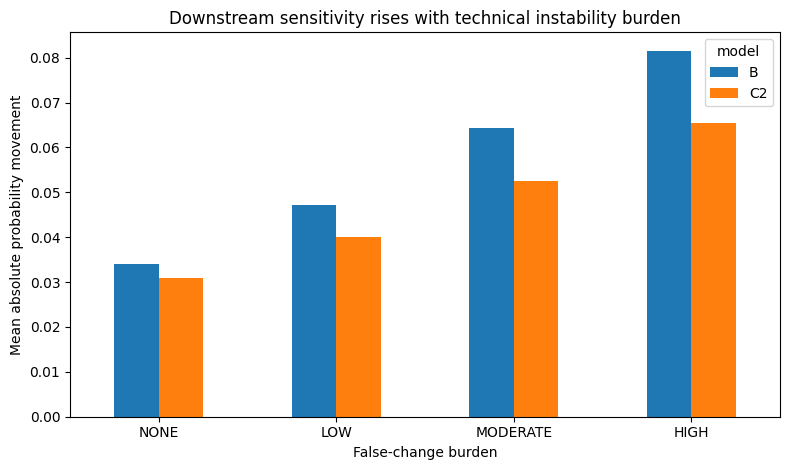

In [18]:

# Publication-oriented burden figure
plot = burden_consequence.pivot(
    index="burden",
    columns="model",
    values="mean_abs_prob_move"
).reindex(burden_order)

ax = plot[["B", "C2"]].plot(
    kind="bar",
    figsize=(8, 4.8)
)

ax.set_ylabel("Mean absolute probability movement")
ax.set_xlabel("False-change burden")
ax.set_title("Downstream sensitivity rises with technical instability burden")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(
    OUTDIR / "figure_false_change_burden_B_vs_C2.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


## 14. Clean A/B/C comparison and clean-to-shift degradation

In [19]:

clean = clean_metrics.set_index("model")
shift_mean = shift_metrics.groupby("model").mean(numeric_only=True)

degradation_rows = []

for m in model_names:
    degradation_rows.append({
        "model": m,
        "clean_AUROC": clean.loc[m, "AUROC"],
        "shift_AUROC_mean": shift_mean.loc[m, "AUROC"],
        "AUROC_degradation": shift_mean.loc[m, "AUROC"] - clean.loc[m, "AUROC"],
        "clean_Brier": clean.loc[m, "Brier"],
        "shift_Brier_mean": shift_mean.loc[m, "Brier"],
        "Brier_degradation": shift_mean.loc[m, "Brier"] - clean.loc[m, "Brier"],
        "clean_ECE": clean.loc[m, "ECE"],
        "shift_ECE_mean": shift_mean.loc[m, "ECE"],
        "ECE_degradation": shift_mean.loc[m, "ECE"] - clean.loc[m, "ECE"],
    })

degradation = pd.DataFrame(degradation_rows)
degradation.round(4)


,model,clean_AUROC,shift_AUROC_mean,AUROC_degradation,clean_Brier,shift_Brier_mean,Brier_degradation,clean_ECE,shift_ECE_mean,ECE_degradation
0,A,0.7578,0.7578,0.0000,0.2004,0.2004,0.0000,0.0565,0.0565,0.0000
1,B,0.7574,0.7415,-0.0159,0.2010,0.2090,0.0079,0.0547,0.0765,0.0218
2,C1,0.7591,0.7304,-0.0287,0.1981,0.2135,0.0153,0.0534,0.0627,0.0093
3,C2,0.7465,0.7340,-0.0125,0.2041,0.2096,0.0055,0.0681,0.0725,0.0044
4,C3,0.7190,0.7082,-0.0108,0.2229,0.2254,0.0025,0.0978,0.1057,0.0080


## 15. Publication-oriented figures

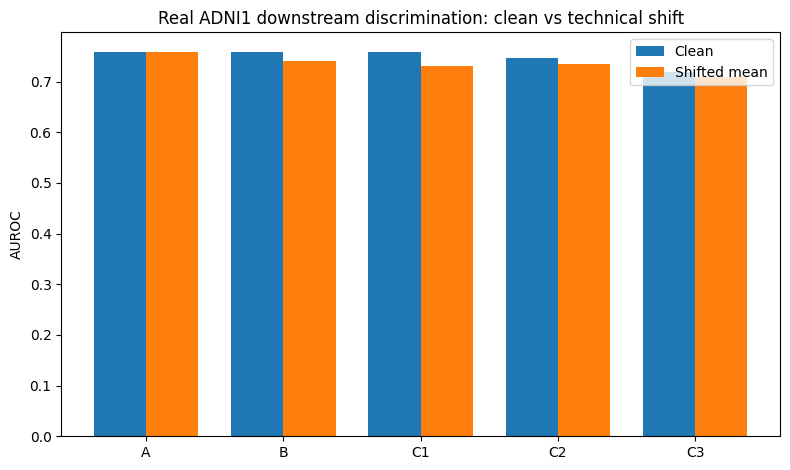

In [20]:

# Figure 1: clean vs shifted AUROC
fig, ax = plt.subplots(figsize=(8, 4.8))
x = np.arange(len(model_names))
clean_vals = [clean.loc[m, "AUROC"] for m in model_names]
shift_vals = [shift_mean.loc[m, "AUROC"] for m in model_names]

w = 0.38
ax.bar(x - w/2, clean_vals, width=w, label="Clean")
ax.bar(x + w/2, shift_vals, width=w, label="Shifted mean")
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylabel("AUROC")
ax.set_title("Real ADNI1 downstream discrimination: clean vs technical shift")
ax.legend()
plt.tight_layout()
plt.savefig(OUTDIR / "figure_clean_vs_shift_auroc.png", dpi=300, bbox_inches="tight")
plt.show()


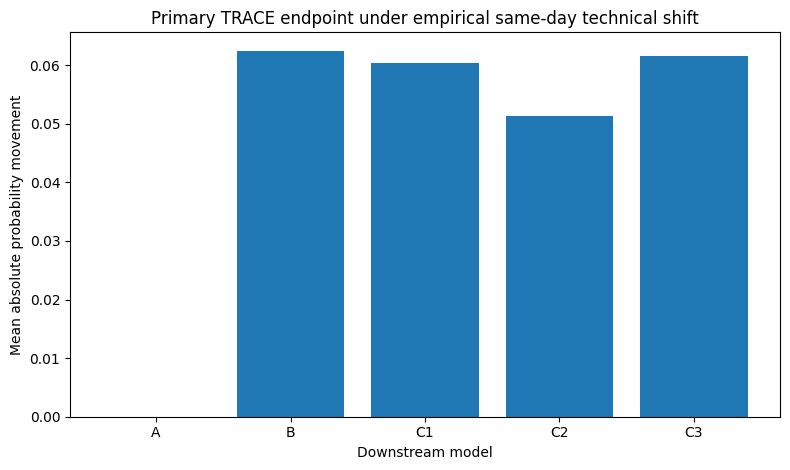

In [21]:

# Figure 2: primary robustness endpoint
plot_move = movement_summary.set_index("model").loc[model_names]

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.bar(plot_move.index, plot_move["mean_abs_prob_move"])
ax.set_ylabel("Mean absolute probability movement")
ax.set_xlabel("Downstream model")
ax.set_title("Primary TRACE endpoint under empirical same-day technical shift")
plt.tight_layout()
plt.savefig(OUTDIR / "figure_probability_movement.png", dpi=300, bbox_inches="tight")
plt.show()


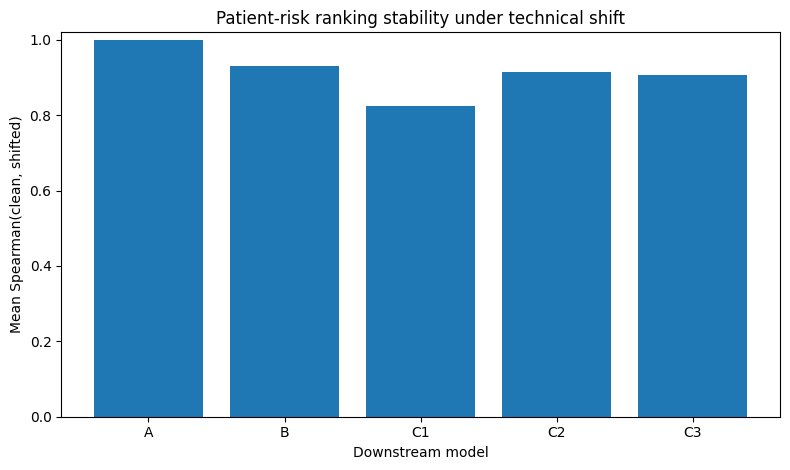

In [22]:

# Figure 3: ranking stability
rs = ranking_summary.set_index("model").loc[model_names]

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.bar(rs.index, rs["spearman_mean"])
ax.set_ylim(0, 1.02)
ax.set_ylabel("Mean Spearman(clean, shifted)")
ax.set_xlabel("Downstream model")
ax.set_title("Patient-risk ranking stability under technical shift")
plt.tight_layout()
plt.savefig(OUTDIR / "figure_ranking_stability.png", dpi=300, bbox_inches="tight")
plt.show()


## 16. Aggregate exports

In [23]:

clean_metrics.to_csv(OUTDIR / "table_clean_metrics.csv", index=False)
shift_metrics.to_csv(OUTDIR / "table_shift_metrics_all_replicates.csv", index=False)
shift_summary.to_csv(OUTDIR / "table_shift_summary.csv", index=False)
movement_summary.to_csv(OUTDIR / "table_probability_movement.csv", index=False)
primary_bootstrap.to_csv(OUTDIR / "table_primary_endpoint_bootstrap.csv", index=False)
ranking_summary.to_csv(OUTDIR / "table_ranking_stability.csv", index=False)
degradation.to_csv(OUTDIR / "table_clean_to_shift_degradation.csv", index=False)

burden_consequence.to_csv(
    OUTDIR / "table_false_change_burden_consequence.csv",
    index=False
)
subject_burden.to_csv(
    OUTDIR / "table_false_change_burden_subject_summary_PRIVATE.csv",
    index=False
)
burden_bootstrap.to_csv(
    OUTDIR / "table_false_change_burden_bootstrap.csv",
    index=False
)
burden_trend.to_csv(
    OUTDIR / "table_false_change_burden_trend.csv",
    index=False
)
print("Aggregate outputs:")
for p in sorted(OUTDIR.glob("*")):
    print(" -", p.name)

Aggregate outputs:
 - figure_clean_vs_shift_auroc.png
 - figure_false_change_burden_B_vs_C2.png
 - figure_probability_movement.png
 - figure_ranking_stability.png
 - table_clean_metrics.csv
 - table_clean_to_shift_degradation.csv
 - table_false_change_burden_bootstrap.csv
 - table_false_change_burden_consequence.csv
 - table_false_change_burden_subject_summary_PRIVATE.csv
 - table_false_change_burden_trend.csv
 - table_primary_endpoint_bootstrap.csv
 - table_probability_movement.csv
 - table_ranking_stability.csv
 - table_shift_metrics_all_replicates.csv
 - table_shift_summary.csv


## 17. Reproducibility manifest

In [24]:

def sha256_file(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

manifest = {
    "notebook": "21B-REAL-FINAL",
    "seed": SEED,
    "shift_replicates": SHIFT_REPS,
    "bootstrap_replicates": BOOT_REPS,
    "inputs": {
        GATE_PATH.name: sha256_file(GATE_PATH),
        REPEAT_PATH.name: sha256_file(REPEAT_PATH),
        CLIN_PATH.name: sha256_file(CLIN_PATH),
    },
    "subjects": int(len(df)),
    "clinical_predictors": available_clinical,
    "models": {
        "A": "clinical baseline only",
        "B": "clinical + raw signed 12-month MRI percent change",
        "C1": "clinical + trusted-only MRI evidence",
        "C2": "clinical + reliability-weighted MRI evidence",
        "C3": "clinical + raw MRI + TRACE state/ratio/root-cause context",
    },
    "primary_endpoint": "mean absolute downstream probability movement under empirical same-day technical shifts",
    "technical_shift_source": "real ADNI1 same-day different-acquisition repeat ratios",
    "false_change_burden": "count of 7 biological MRI features with direction flip or Q90 envelope crossing; categories 0, 1, 2-3, 4-7",
}

with open(OUTDIR / "manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)

manifest


{'notebook': '21B-REAL-FINAL',
 'seed': 2027,
 'shift_replicates': 100,
 'bootstrap_replicates': 2000,
 'inputs': {'TRACE_ADNI1_20B_REAL_CORRECTED_GATED_PRIVATE.csv': 'e2a52205f1ba5889ff5cae54e3db6bd7bf637ca30c7ded940721032fd5623f44',
  'TRACE_ADNI1_repeat_pairs_REAL.csv': '3a600b5cf11df11d2511e51ebbc933eed8be3d04305b7b281271d058c37ab926',
  'TRACE_ADNI1_clinical_baseline_REAL.csv': 'fcd5a7655867d860bf0a3785648d81c92724596ad5f8b8dfd8bccbdccb59c860'},
 'subjects': 258,
 'clinical_predictors': ['AGE',
  'SEX_FEMALE',
  'EDUCATION_YEARS',
  'MMSE',
  'CDR_SCORE',
  'FAQ_TOTAL'],
 'models': {'A': 'clinical baseline only',
  'B': 'clinical + raw signed 12-month MRI percent change',
  'C1': 'clinical + trusted-only MRI evidence',
  'C2': 'clinical + reliability-weighted MRI evidence',
  'C3': 'clinical + raw MRI + TRACE state/ratio/root-cause context'},
 'primary_endpoint': 'mean absolute downstream probability movement under empirical same-day technical shifts',
 'technical_shift_source': '

## 18. 21B-REAL-FINAL readiness summary

In [25]:

print("============================================================")
print("21B-REAL-FINAL READINESS SUMMARY")
print("============================================================")

print("Subjects:", len(df))
print("pMCI:", int(y.sum()))
print("sMCI:", int((1-y).sum()))
print("Clinical predictors:", available_clinical)
print("Shift replicates:", SHIFT_REPS)

print("\nCLEAN MODEL METRICS")
display(clean_metrics.round(4))

print("\nSHIFTED MODEL SUMMARY")
display(shift_summary.round(4))

print("\nPRIMARY ENDPOINT — ABSOLUTE PROBABILITY MOVEMENT")
display(movement_summary.round(5))

print("\nPRIMARY PAIRED BOOTSTRAP: C - B (negative favors TRACE)")
display(primary_bootstrap.round(5))

print("\nRANKING STABILITY")
display(ranking_summary.round(4))

print("\nFALSE-CHANGE BURDEN DISTRIBUTION")
burden_dist = (
    pd.Series(burden_cat.flatten())
      .value_counts()
      .reindex(["NONE", "LOW", "MODERATE", "HIGH"], fill_value=0)
)
burden_dist_pct = 100 * burden_dist / burden_dist.sum()
display(pd.DataFrame({
    "n_subject_shift_pairs": burden_dist,
    "pct": burden_dist_pct.round(2)
}))

print("\nDOWNSTREAM MOVEMENT BY FALSE-CHANGE BURDEN")
display(burden_consequence.round(4))

print("\n>=2-FEATURE BURDEN PAIRED SUBJECT BOOTSTRAP")
display(burden_bootstrap.round(5))

print("\nBURDEN-RESPONSE TREND")
display(burden_trend.round(4))

print("\nCLEAN-TO-SHIFT DEGRADATION")
display(degradation.round(4))

print("\nREADINESS CHECKS")
checks = {
    "real_clinical_baseline_model_A": len(available_clinical) >= 3,
    "real_raw_imaging_model_B": True,
    "trace_C1_trusted_only": True,
    "trace_C2_reliability_weighted": True,
    "trace_C3_full_context": True,
    "same_subject_outer_splits_all_models": True,
    "empirical_real_repeat_shift": len(acq) == 75,
    "paired_primary_endpoint_bootstrap": len(primary_bootstrap) == 3,
    "false_change_burden_not_binary_any_feature": True,
    "burden_endpoint_aggregated_within_subject": True,
    "outcome_not_used_to_define_TRACE_gate": True,
}

for name, passed in checks.items():
    print(f"{name}: {'PASS' if passed else 'CHECK'}")

print("\nFINAL INTERPRETATION GUARDRAIL")
print("TRACE is evaluated as an evidence-reliability and propagation-control method.")
print("Do not claim diagnostic superiority, clinical safety, or biological ground truth.")


21B-REAL-FINAL READINESS SUMMARY
Subjects: 258
pMCI: 140
sMCI: 118
Clinical predictors: ['AGE', 'SEX_FEMALE', 'EDUCATION_YEARS', 'MMSE', 'CDR_SCORE', 'FAQ_TOTAL']
Shift replicates: 100

CLEAN MODEL METRICS


,model,AUROC,AUPRC,Brier,ECE,CalibrationIntercept,CalibrationSlope,ConfidentWrongRate
0,A,0.7578,0.7919,0.2004,0.0565,0.0371,0.9098,0.0388
1,B,0.7574,0.7902,0.2010,0.0547,0.0473,0.7831,0.0543
2,C1,0.7591,0.8023,0.1981,0.0534,0.0282,1.0203,0.0155
3,C2,0.7465,0.7931,0.2041,0.0681,0.0368,0.8571,0.0426
4,C3,0.7190,0.7089,0.2229,0.0978,0.1077,0.5339,0.0775



SHIFTED MODEL SUMMARY


,model,AUROC_mean,AUROC_p025,AUROC_p975,Brier_mean,Brier_p025,Brier_p975,ECE_mean,ConfidentWrong_mean
0,A,0.7578,0.7578,0.7578,0.2004,0.2004,0.2004,0.0565,0.0388
1,B,0.7415,0.7178,0.7661,0.2090,0.1976,0.2204,0.0765,0.0676
2,C1,0.7304,0.6928,0.7692,0.2135,0.1980,0.2286,0.0627,0.0491
3,C2,0.7340,0.7109,0.7547,0.2096,0.2019,0.2185,0.0725,0.0498
4,C3,0.7082,0.6840,0.7325,0.2254,0.2154,0.2352,0.1057,0.0705



PRIMARY ENDPOINT — ABSOLUTE PROBABILITY MOVEMENT


...


BURDEN-RESPONSE TREND


,model,spearman_burden_vs_prob_move
0,B,0.1979
1,C1,0.0587
2,C2,0.0810
3,C3,0.1445



CLEAN-TO-SHIFT DEGRADATION


,model,clean_AUROC,shift_AUROC_mean,AUROC_degradation,clean_Brier,shift_Brier_mean,Brier_degradation,clean_ECE,shift_ECE_mean,ECE_degradation
0,A,0.7578,0.7578,0.0000,0.2004,0.2004,0.0000,0.0565,0.0565,0.0000
1,B,0.7574,0.7415,-0.0159,0.2010,0.2090,0.0079,0.0547,0.0765,0.0218
2,C1,0.7591,0.7304,-0.0287,0.1981,0.2135,0.0153,0.0534,0.0627,0.0093
3,C2,0.7465,0.7340,-0.0125,0.2041,0.2096,0.0055,0.0681,0.0725,0.0044
4,C3,0.7190,0.7082,-0.0108,0.2229,0.2254,0.0025,0.0978,0.1057,0.0080



READINESS CHECKS
real_clinical_baseline_model_A: PASS
real_raw_imaging_model_B: PASS
trace_C1_trusted_only: PASS
trace_C2_reliability_weighted: PASS
trace_C3_full_context: PASS
same_subject_outer_splits_all_models: PASS
empirical_real_repeat_shift: PASS
paired_primary_endpoint_bootstrap: PASS
false_change_burden_not_binary_any_feature: PASS
burden_endpoint_aggregated_within_subject: PASS
outcome_not_used_to_define_TRACE_gate: PASS

FINAL INTERPRETATION GUARDRAIL
TRACE is evaluated as an evidence-reliability and propagation-control method.
Do not claim diagnostic superiority, clinical safety, or biological ground truth.



## 19. Manuscript-ready Results draft

This cell writes a conservative Results paragraph based only on the executed real-data outputs. It deliberately avoids claiming diagnostic superiority.


In [26]:

def _row(df_, model):
    return df_.loc[df_["model"] == model].iloc[0]

A = _row(clean_metrics, "A")
B = _row(clean_metrics, "B")
C2 = _row(clean_metrics, "C2")

Bs = _row(shift_summary, "B")
C2s = _row(shift_summary, "C2")

Bm = _row(movement_summary, "B")
C2m = _row(movement_summary, "C2")

c2_boot = primary_bootstrap.loc[
    primary_bootstrap["comparison"] == "C2 - B"
].iloc[0]

burden_c2_boot = burden_bootstrap.loc[
    burden_bootstrap["comparison"] == "C2 - B"
].iloc[0]

reduction_pct = 100 * (
    1 - C2m["mean_abs_prob_move"] / Bm["mean_abs_prob_move"]
)

results_text = f'''
In the real ADNI1 downstream experiment, the clinical-only baseline model
(Model A) achieved an AUROC of {A["AUROC"]:.3f}, while adding unfiltered
12-month MRI change features (Model B) produced an AUROC of {B["AUROC"]:.3f}.
Under empirically sampled same-day acquisition shifts, mean Model B AUROC was
{Bs["AUROC_mean"]:.3f}. Reliability-weighted TRACE evidence (C2) did not improve
clean discrimination (AUROC {C2["AUROC"]:.3f}), but reduced mean absolute
prediction movement from {Bm["mean_abs_prob_move"]:.4f} for Model B to
{C2m["mean_abs_prob_move"]:.4f}, a {reduction_pct:.1f}% reduction.
The paired subject bootstrap difference for C2 versus B was
{c2_boot["mean_difference"]:.4f} (95% CI {c2_boot["ci_low"]:.4f} to
{c2_boot["ci_high"]:.4f}). In the refined false-change analysis, technical
instability was represented as the number of biomarker channels showing either
a direction reversal or a Q90 reliability-envelope crossing. For perturbations
affecting at least two biomarkers, the paired subject-level C2-versus-B
difference in mean probability movement was
{burden_c2_boot["mean_difference"]:.4f} (95% CI
{burden_c2_boot["ci_low"]:.4f} to {burden_c2_boot["ci_high"]:.4f}).
These findings support TRACE as a reliability-aware evidence propagation
strategy that attenuates downstream sensitivity to acquisition variability;
they do not establish diagnostic superiority or clinical safety.
'''.strip()

print(results_text)

with open(OUTDIR / "manuscript_ready_results.txt", "w") as f:
    f.write(results_text)

print("\nSaved:", OUTDIR / "manuscript_ready_results.txt")


In the real ADNI1 downstream experiment, the clinical-only baseline model
(Model A) achieved an AUROC of 0.758, while adding unfiltered
12-month MRI change features (Model B) produced an AUROC of 0.757.
Under empirically sampled same-day acquisition shifts, mean Model B AUROC was
0.741. Reliability-weighted TRACE evidence (C2) did not improve
clean discrimination (AUROC 0.746), but reduced mean absolute
prediction movement from 0.0625 for Model B to
0.0513, a 17.8% reduction.
The paired subject bootstrap difference for C2 versus B was
-0.0111 (95% CI -0.0161 to
-0.0060). In the refined false-change analysis, technical
instability was represented as the number of biomarker channels showing either
a direction reversal or a Q90 reliability-envelope crossing. For perturbations
affecting at least two biomarkers, the paired subject-level C2-versus-B
difference in mean probability movement was
-0.0124 (95% CI
-0.0180 to -0.0067).
These findings support TRACE as a reliability-aware evidence pr